# Wavefront visualisation: perfect beam down, aberrated beam up

Visualises the two fields `optics/generate_wavefront.py` builds for an
interpolated (`wtype=interpolated`) ais++ beam under the mirror-reflection
model: a perfect Gaussian beam travels down to the retroreflecting mirror
at z=`mirror_z` and picks up a wavefront aberration on reflection (mirror
surface imperfections), so the upward beam is the aberrated one. The
aberration is imprinted **only at the mirror plane** and then actually
**propagated** (Fresnel/paraxial) to every other z -- unlike ais++'s own
native `wtype=confocal zernikecoeff_N`, which applies the same aberration
pattern regardless of how far the atom is from the mirror (`GetZernikePhase`
depends only on transverse position, never on z). This notebook shows both
the imprinted pattern at the mirror and how it diffracts away from it.

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

REPO = Path('..').resolve()
sys.path.insert(0, str(REPO.parent / 'local' / 'aispy'))
from aispy.utils import kz as AISPY_KZ

from aisoptics import Backend, GaussianBeam, GridSpec, FieldPlane, ParaxialPropagator
from aisoptics.fields.perturbations import FourierModePerturbation, FourierPerturbation, ZernikeAberration, ZernikeSum

# --- config: match generate_wavefront.py's defaults / your --mode, --zernike flags ---
WAVELENGTH = 2 * np.pi / float(AISPY_KZ)
ZR = 450.085
WAIST = np.sqrt(2 * ZR / float(AISPY_KZ))
FOCUS_Z = 0.0
MIRROR_Z = 0.0        # reference plane the aberration is imprinted at
BEAM_RADIUS = 0.03    # Zernike aperture; keep <= your grid's xy half-width

MODES = [
    # FourierModePerturbation(qx=1571.0, qy=0.0, amplitude=0.15, phase=0.0),
]
ZTERMS = [
    ZernikeAberration(noll_index=4, amplitude=0.05, beam_radius=BEAM_RADIUS),  # defocus
    # ZernikeAberration(noll_index=11, amplitude=0.02, beam_radius=BEAM_RADIUS),  # spherical
]

print(f'wavelength={WAVELENGTH*1e9:.2f} nm  waist={WAIST*1e3:.3f} mm')

wavelength=698.45 nm  waist=10.003 mm


In [2]:
backend = Backend("numpy")
down_beam = GaussianBeam(wavelength=WAVELENGTH, waist=WAIST, focus_z=FOCUS_Z,
                          propagation_direction="-z", backend=backend)
up_beam_ref = GaussianBeam(wavelength=WAVELENGTH, waist=WAIST, focus_z=FOCUS_Z,
                            propagation_direction="+z", backend=backend)


def aberration_phase_fn(x, y, z=MIRROR_Z):
    phi = np.zeros_like(np.asarray(x, dtype=float))
    if ZTERMS:
        phi = phi + ZernikeSum(ZTERMS).value(x, y, z)
    if MODES:
        phi = phi + FourierPerturbation(modes=MODES).value(x, y, z)
    return phi


# "up_field_obj" below = the field AT THE MIRROR PLANE ONLY, matching what
# generate_wavefront.py imprints before propagating -- used by the next two
# sections (phase/amplitude at the mirror, isolated aberration). The
# propagation section further down shows what happens away from it.

### Phase and amplitude at the mirror plane (z=0)

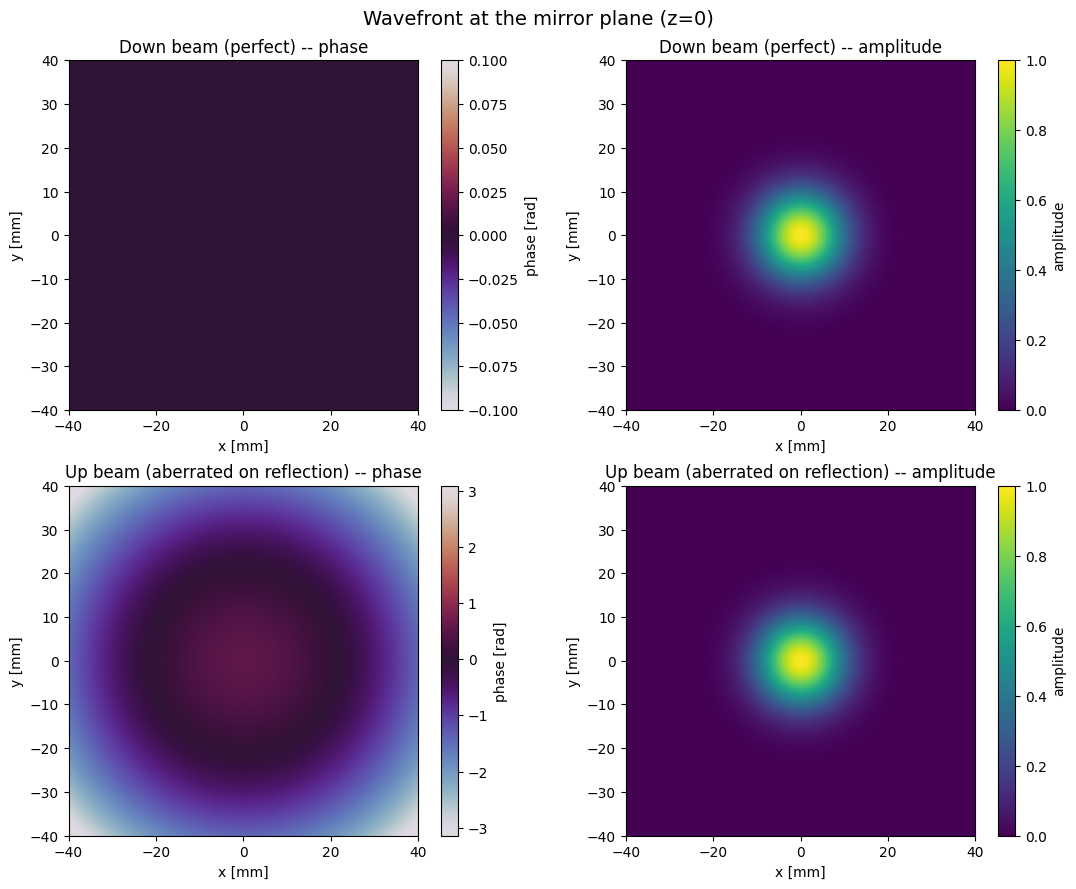

In [3]:
N = 121
half = 4 * WAIST   # a few beam waists across
x = np.linspace(-half, half, N)
y = np.linspace(-half, half, N)
X, Y = np.meshgrid(x, y, indexing='ij')
Z = np.zeros_like(X)

down_complex = down_beam.complex_amplitude(X, Y, Z)
up_perfect = up_beam_ref.complex_amplitude(X, Y, Z)
up_complex = up_perfect * np.exp(1j * aberration_phase_fn(X, Y, MIRROR_Z))

down_phase, down_amp = np.angle(down_complex), np.abs(down_complex)
up_phase, up_amp = np.angle(up_complex), np.abs(up_complex)

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
extent = [x[0]*1e3, x[-1]*1e3, y[0]*1e3, y[-1]*1e3]

im = axes[0,0].imshow(down_phase.T, origin='lower', extent=extent, cmap='twilight')
plt.colorbar(im, ax=axes[0,0], label='phase [rad]')
axes[0,0].set_title('Down beam (perfect) -- phase')

im = axes[0,1].imshow(down_amp.T, origin='lower', extent=extent, cmap='viridis')
plt.colorbar(im, ax=axes[0,1], label='amplitude')
axes[0,1].set_title('Down beam (perfect) -- amplitude')

im = axes[1,0].imshow(up_phase.T, origin='lower', extent=extent, cmap='twilight')
plt.colorbar(im, ax=axes[1,0], label='phase [rad]')
axes[1,0].set_title('Up beam (aberrated on reflection) -- phase')

im = axes[1,1].imshow(up_amp.T, origin='lower', extent=extent, cmap='viridis')
plt.colorbar(im, ax=axes[1,1], label='amplitude')
axes[1,1].set_title('Up beam (aberrated on reflection) -- amplitude')

for ax in axes.flat:
    ax.set_xlabel('x [mm]'); ax.set_ylabel('y [mm]')
fig.suptitle('Wavefront at the mirror plane (z=0)', fontsize=14)
fig.tight_layout()
plt.show()

### Just the aberration: up-beam phase minus down-beam phase

Isolates what the mirror actually did to the wavefront -- should match the
Fourier-mode sum in `MODES` above (this is a direct sanity check that the
aberration you specified is what actually got sampled).

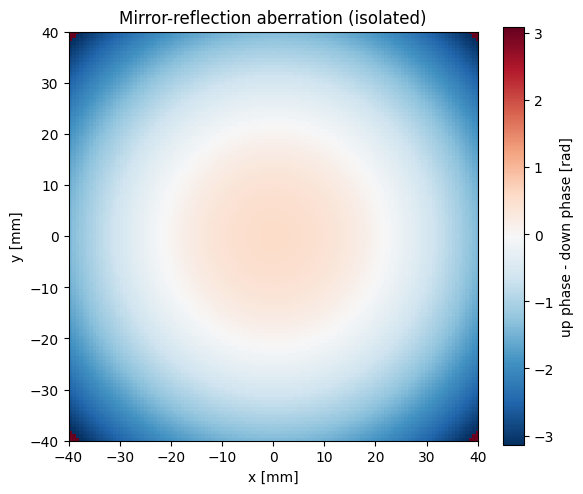

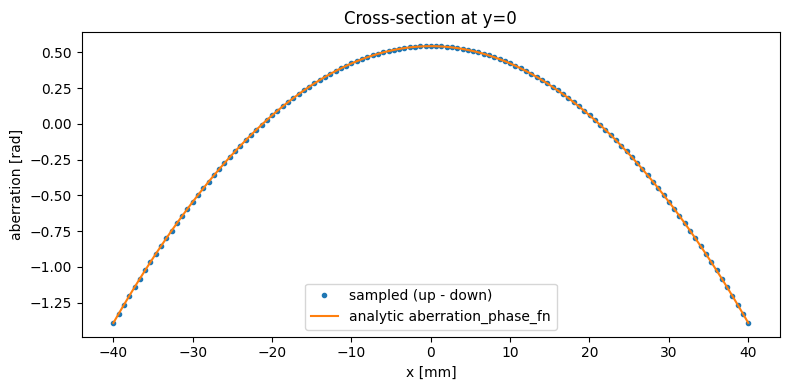

In [4]:
aberration = np.angle(np.exp(1j * (up_phase - down_phase)))  # wrap to (-pi, pi]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(aberration.T, origin='lower', extent=extent, cmap='RdBu_r')
plt.colorbar(im, ax=ax, label='up phase - down phase [rad]')
ax.set_title('Mirror-reflection aberration (isolated)')
ax.set_xlabel('x [mm]'); ax.set_ylabel('y [mm]')
plt.tight_layout()
plt.show()

# 1D cross-section at y=0, compared to the analytic sum of Fourier modes
iy0 = N // 2
analytic = aberration_phase_fn(x, np.zeros_like(x), MIRROR_Z)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x * 1e3, aberration[:, iy0], 'o', ms=3, label='sampled (up - down)')
ax.plot(x * 1e3, analytic, '-', lw=1.5, label='analytic aberration_phase_fn')
ax.set_xlabel('x [mm]'); ax.set_ylabel('aberration [rad]')
ax.set_title('Cross-section at y=0')
ax.legend()
plt.tight_layout()
plt.show()

### 3D surface of the up-beam wavefront

Same phase data as above, as a surface -- sometimes easier to read off the
mode structure (ripples, tilt, curvature) than a 2D heatmap.

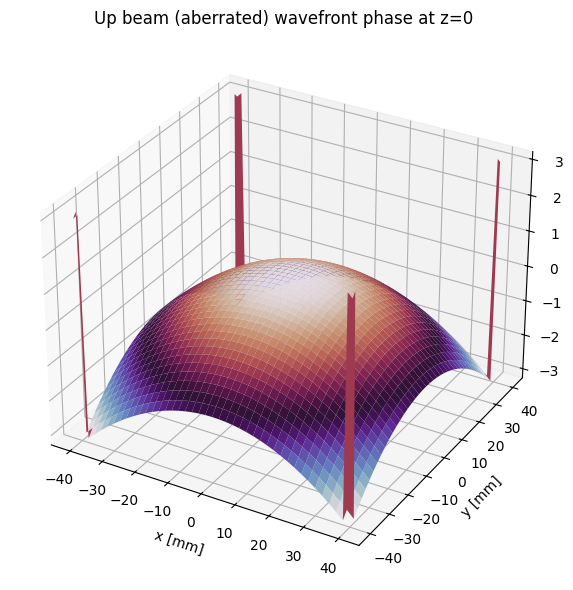

In [5]:
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X * 1e3, Y * 1e3, up_phase, cmap='twilight', linewidth=0, antialiased=True)
ax.set_xlabel('x [mm]'); ax.set_ylabel('y [mm]'); ax.set_zlabel('phase [rad]')
ax.set_title('Up beam (aberrated) wavefront phase at z=0')
plt.tight_layout()
plt.show()

## Propagation: does the aberration actually diffract?

Everything above lives at `z=mirror_z` only. This is the point of building
the aberration at one plane and propagating it rather than copying it to
every z (as ais++'s native `wtype=confocal zernikecoeff_N` does): a real
aberrated wavefront's structure changes with distance from where it was
imprinted. Below, `ParaxialPropagator` propagates the mirror-plane field to
a full z range, and we compare the aberration pattern at the mirror against
the same pattern extracted at increasing z. If propagation is doing
something physically real, the residual should match the mirror-plane
pattern closely near z=mirror_z and increasingly diverge from it further
away -- **not** stay frozen.

Two caveats validated during development (see `generate_wavefront.py`'s
module docstring): the transverse grid must be wide enough for the beam's
amplitude to decay near zero at the edges (checked below), and Zernike
terms are only meaningful for rho=r/beam_radius <= 1 -- points outside the
aperture are extrapolated raw polynomial values, not physical.

In [6]:
# 3D grid + propagation
Nxy, Nz = 41, 41
half_xy = 4 * WAIST
x3 = np.linspace(-half_xy, half_xy, Nxy)
y3 = np.linspace(-half_xy, half_xy, Nxy)
z3 = np.linspace(-1.0, 25.0, Nz)
X3, Y3 = np.meshgrid(x3, y3, indexing='ij')

perfect_at_mirror = up_beam_ref.complex_amplitude(X3, Y3, MIRROR_Z * np.ones_like(X3))
aberration_at_mirror = aberration_phase_fn(X3, Y3, MIRROR_Z)
aberrated_at_mirror = perfect_at_mirror * np.exp(1j * aberration_at_mirror)

edge_amp = np.abs(np.concatenate([aberrated_at_mirror[0, :], aberrated_at_mirror[-1, :],
                                   aberrated_at_mirror[:, 0], aberrated_at_mirror[:, -1]])).max()
edge_ratio = edge_amp / np.abs(aberrated_at_mirror).max()
print(f'edge amplitude / peak = {edge_ratio:.2e}  (want << 1e-3, else FFT wrap-around corrupts the result)')

plane = FieldPlane(x=x3, y=y3, values=aberrated_at_mirror, z0=MIRROR_Z, wavelength=WAVELENGTH, backend=backend)
plane_noaberr = FieldPlane(x=x3, y=y3, values=perfect_at_mirror, z0=MIRROR_Z, wavelength=WAVELENGTH, backend=backend)
propagator = ParaxialPropagator()
field_up_3d = propagator.propagate_to_many(plane, z3)
field_up_noaberr_3d = propagator.propagate_to_many(plane_noaberr, z3)

edge amplitude / peak = 1.13e-07  (want << 1e-3, else FFT wrap-around corrupts the result)


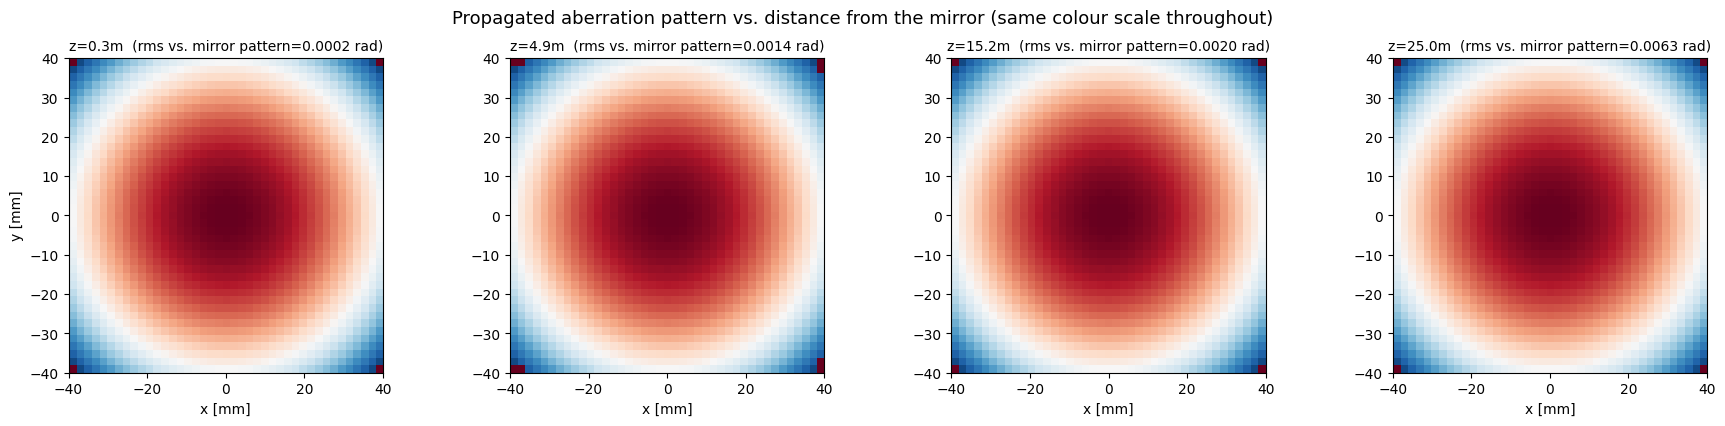

z [m]    rms deviation from rigid mirror-plane pattern [rad]
  0.30   0.00019
  4.85   0.00138
 15.25   0.00199
 25.00   0.00626

Growing rms with |z| = real diffraction. ~0 at every z would mean propagation
is doing nothing (a bug); large/noisy values at small z would mean the grid is
under-resolved or the edge-amplitude check above failed.


In [7]:
# Residual (aberrated - unaberrated, same propagation) vs the rigid mirror-plane
# pattern, at several z -- rms difference should grow with |z - mirror_z|.
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
target_zs = [0.0, 5.0, 15.0, 25.0]
rms_vs_z = []
for ax, tz in zip(axes, target_zs):
    iz = int(np.argmin(np.abs(z3 - tz)))
    residual = np.angle(np.exp(1j * (field_up_3d.phase[:, :, iz] - field_up_noaberr_3d.phase[:, :, iz])))
    wrapped_diff = np.angle(np.exp(1j * (residual - aberration_at_mirror)))
    rms = np.sqrt(np.mean(wrapped_diff**2))
    rms_vs_z.append((z3[iz], rms))
    im = ax.imshow(residual.T, origin='lower', extent=[x3[0]*1e3, x3[-1]*1e3, y3[0]*1e3, y3[-1]*1e3],
                   cmap='RdBu_r', vmin=aberration_at_mirror.min(), vmax=aberration_at_mirror.max())
    ax.set_title(f'z={z3[iz]:.1f}m  (rms vs. mirror pattern={rms:.4f} rad)', fontsize=10)
    ax.set_xlabel('x [mm]')
axes[0].set_ylabel('y [mm]')
fig.suptitle('Propagated aberration pattern vs. distance from the mirror (same colour scale throughout)', fontsize=13)
fig.tight_layout()
plt.show()

print('z [m]    rms deviation from rigid mirror-plane pattern [rad]')
for z, rms in rms_vs_z:
    print(f'{z:6.2f}   {rms:.5f}')
print('\nGrowing rms with |z| = real diffraction. ~0 at every z would mean propagation')
print('is doing nothing (a bug); large/noisy values at small z would mean the grid is')
print('under-resolved or the edge-amplitude check above failed.')